# EDA

Данные: секундные показания магнитного датчика за год  
Колонки: `seconds` - счётчик времени (шаг 3 сек), `value` - показание датчика, `quality` - флаг качества, `accuracy` - дополнительный флаг  


## Импорты и загрузка данных

Загружаем библиотеки и читаем файл. Сразу смотрим базовую статистику — минимум, максимум, среднее — чтобы понять масштаб значений и наличие очевидных аномалий.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import medfilt
pd.set_option('future.no_silent_downcasting', True)

plt.rcParams['figure.dpi'] = 100


STEP = 3
PTS_MIN = 20     
PTS_HOUR = 1200    
PTS_DAY = 28800   

In [ ]:
df = pd.read_csv('ARS_pos1_2023.csv')
df.columns = ['seconds', 'value', 'quality', 'accuracy']

print(df.head(10))
print(f'Размер - {df.shape}')
print(f'Период: {df["seconds"].min()} – {df["seconds"].max()} секунд')
print(f'Длительность: ~{df["seconds"].max() / 86400:.0f} дней')

   seconds   value  quality  accuracy
0        3  157720        2         0
1        6  157726        3         0
2        9  157708        2         0
3       12  157728        2         0
4       15  157720        2         0
5       18  157720        2         0
6       21  157744        2         0
7       24  157744        2         0
8       27  157754        2         0
9       30  157758        2         0
Размер - (10079174, 4)
Период: 3 – 31622399 секунд
Длительность: ~366 дней


## Kолонка accuracy

Смотрим сколько ненулевых зачений, если очень мало - можем ее игнорировать

In [5]:
print(f'Уникальных значений accuracy: {df["accuracy"].nunique()}')
print(f'Ненулевых: {(df["accuracy"] != 0).sum()} ({100*(df["accuracy"] != 0).mean():.4f}%)')
print(df['accuracy'].value_counts().head(10))

df['accuracy_flag'] = (df['accuracy'] != 0).astype(int)
print(f'\nПомечено точек: {df["accuracy_flag"].sum()}')

Уникальных значений accuracy: 4
Ненулевых: 53 (0.0005%)
accuracy
0    10079121
4          31
1          12
2          10
Name: count, dtype: int64

Помечено точек: 53


## Проверяем есть ли пропуски

Смотрим одинаковый ли шаг времени

In [6]:
diffs = df['seconds'].diff().dropna()

print(f'Уникальных значений шага: {diffs.nunique()}')

irregular = diffs[diffs != 3]
print(f'\nНерегулярных шагов: {len(irregular)} ({100*len(irregular)/len(diffs):.4f}%)')
print(irregular.value_counts().tail(20))

Уникальных значений шага: 31

Нерегулярных шагов: 11355 (0.1127%)
seconds
 44.0         1
 993.0        1
 63687.0      1
 128.0        1
 2692.0       1
 12085.0      1
 22.0         1
 903.0        1
 1258309.0    1
 4950.0       1
 28.0         1
 2662.0       1
 1699.0       1
 33.0         1
-11.0         1
 14.0         1
 35.0         1
 6.0          1
 18.0         1
 2188.0       1
Name: count, dtype: int64


## Визуализация 



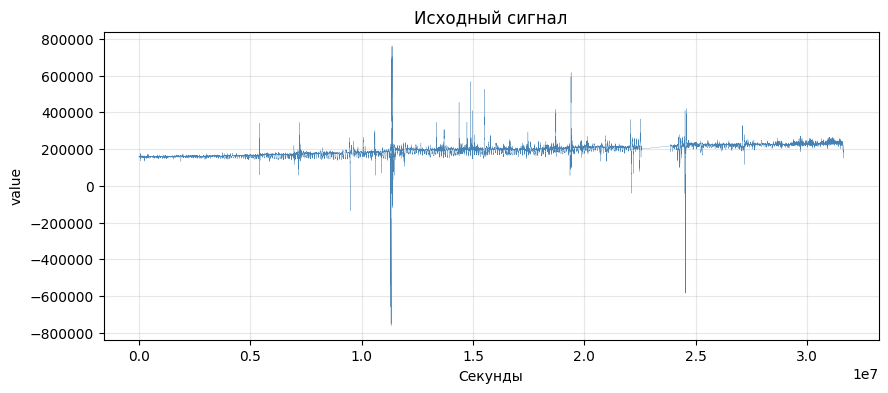

In [22]:
plt.figure(figsize=(10, 4))
plt.plot(df['seconds'], df['value'], lw=0.2, color='steelblue')
plt.title('Исходный сигнал')
plt.xlabel('Секунды')
plt.ylabel('value')
plt.grid(True, alpha=0.3)
plt.show()

## Очистка аномалий через производную

Порог 50 000 выбран на основе анализа: 99.99% всех изменений меньше 9 710, а точек с производной > 50 000 всего 16 из 10 миллионов - это явные артефакты.

Оитрицательные значения не убираем, так как это нормальные бури

Артефактов найдено: 74 точек
Процент от всех данных: 0.0007%


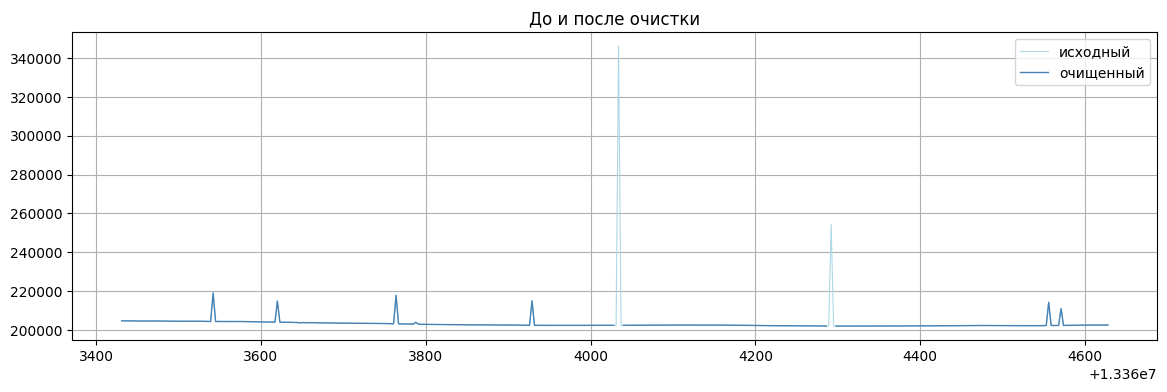

In [8]:
DIFF_THRESHOLD = 50000

df['diff'] = df['value'].diff().abs()

anomaly_mask = df['diff'] > DIFF_THRESHOLD
anomaly_mask = anomaly_mask | anomaly_mask.shift(-1).fillna(False)
df['is_artifact'] = anomaly_mask.astype(int)

print(f'Артефактов найдено: {df["is_artifact"].sum()} точек')
print(f'Процент от всех данных: {100*df["is_artifact"].mean():.4f}%')

# доп колонка с нормальными значениями (вместо пропусков NaN)
df['value_clean'] = df['value'].copy().astype(float)
df.loc[df['is_artifact'] == 1, 'value_clean'] = np.nan


artifact_idx = df[df['is_artifact'] == 1].index[0]
window = df.iloc[max(0, artifact_idx - 200) : artifact_idx + 200]
plt.figure(figsize=(14, 4))
plt.plot(window['seconds'], window['value'], lw=0.8, color='lightblue', label='исходный')
plt.plot(window['seconds'], window['value_clean'], lw=1, color='steelblue', label='очищенный')
plt.title('До и после очистки')
plt.legend()
plt.grid(True)
plt.show()

## Интерполяция небольших пропусков

Берем периоды не большк минуты

In [9]:

df['value_clean'] = df['value_clean'].interpolate(
    method='linear',
    limit=20
)


## Медианный фильтр (сглаживание)

Убирает остаточный мелкий шум. Окно 33 секунды

C:\Users\operator\AppData\Local\Temp\ipykernel_11168\3802750779.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = df['value_clean'].fillna(method='ffill')


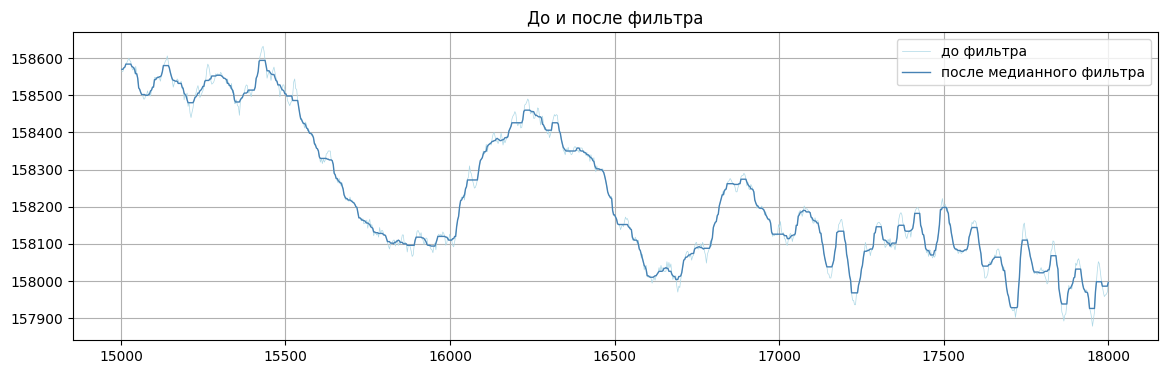

In [10]:
MEDFILT_WINDOW = 11

temp = df['value_clean'].fillna(method='ffill')
df['value_medfilt'] = medfilt(temp.values, kernel_size=MEDFILT_WINDOW).astype(float)

df.loc[df['value_clean'].isna(), 'value_medfilt'] = np.nan

sample = df.iloc[5000:6000]
plt.figure(figsize=(14, 4))
plt.plot(sample['seconds'], sample['value_clean'],  lw=0.5, color='lightblue', label='до фильтра')
plt.plot(sample['seconds'], sample['value_medfilt'], lw=1,  color='steelblue', label='после медианного фильтра')
plt.title('До и после фильтра')
plt.legend()
plt.grid(True)
plt.show()

## Удаление дрейфа

За год сигнал вырос с 90 000 до 160 000 - это дрейф датчика или реальное изменение поля. Без удаления тренда модель будет путать январскую норму (~90 000) с декабрьской нормой (~160 000) и видеть ложные аномалии

Вычисляем медленный тренд через скользящее среднее за 7 суток и вычитаем его из сигнала

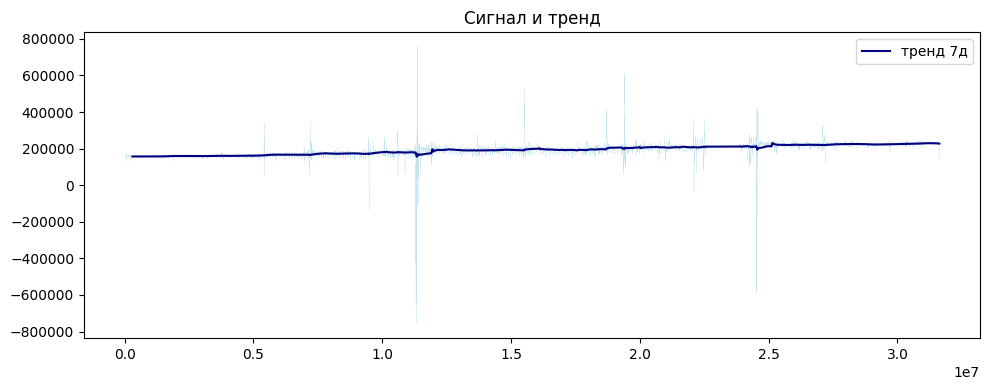

In [21]:
TREND_WINDOW = 7 * PTS_DAY 

df['trend_7d'] = df['value_medfilt'].rolling(
    window=TREND_WINDOW,
    min_periods=TREND_WINDOW // 2,
    center=False
).mean()

df['value_detrended'] = df['value_medfilt'] - df['trend_7d']

fig, axes = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

axes.plot(df['seconds'], df['value_medfilt'], lw=0.2, color='lightblue', alpha=0.7)
axes.plot(df['seconds'], df['trend_7d'], lw=1.5, color='navy', label='тренд 7д')
axes.set_title('Сигнал и тренд')
axes.legend()


plt.tight_layout()
plt.show()

## Feature Engineering

Добавляем час, день, день недели, номер недели и месяц для лучшего обучения модели

In [12]:
pts = df.index  

df['minute'] = (pts // PTS_MIN) % 60
df['hour'] = (pts // PTS_HOUR) % 24
df['day'] = pts // PTS_DAY
df['day_of_week'] = (df['day'] + 2) % 7
df['week_number'] = (df['day'] // 7) + 1

days_map = {
    0: 'Понедельник', 1: 'Вторник',  2: 'Среда',
    3: 'Четверг', 4: 'Пятница', 5: 'Суббота',
    6: 'Воскресенье'
}
df['day_name'] = df['day_of_week'].map(days_map)


days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
cumulative_days = np.cumsum([0] + days_in_month[:-1])
df['month_number'] = np.searchsorted(cumulative_days, df['day'].values, side='right').clip(1, 12)

month_map = {
    1: 'Январь', 2: 'Февраль', 3: 'Март',
    4: 'Апрель', 5: 'Май', 6: 'Июнь',
    7: 'Июль', 8: 'Август', 9: 'Сентябрь',
    10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
}
df['month_name'] = df['month_number'].map(month_map)

df['day_of_year'] = df['day'] % 365

print(f'hour: {df["hour"].min()} – {df["hour"].max()} (ожидаем 0–23)')
print(f'day_of_week: {df["day_of_week"].min()} – {df["day_of_week"].max()} (ожидаем 0–6)')
print(f'month: {df["month_number"].min()} – {df["month_number"].max()} (ожидаем 1–12)')
print(f'week: {df["week_number"].min()} – {df["week_number"].max()}')

print(df.groupby('month_name')['value'].count())

hour: 0 – 23 (ожидаем 0–23)
day_of_week: 0 – 6 (ожидаем 0–6)
month: 1 – 12 (ожидаем 1–12)
week: 1 – 50
month_name
Август      892800
Апрель      864000
Декабрь     459974
Июль        892800
Июнь        864000
Май         892800
Март        892800
Ноябрь      864000
Октябрь     892800
Сентябрь    864000
Февраль     806400
Январь      892800
Name: value, dtype: int64


## Добавляем sin и cos

In [13]:
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

## Добавляем еще лаги и дополнительные признаки

- **Лаг 1ч** - инерция сигнала (корреляция 0.933)
- **lag_mean_30min/1h/3h/6h** - среднее значение сигнала за последние 30 минут/час/3 часа/6 часов
- **slope_1h** - это наклон, направление движения сигнала. Считается как разница между текущим средним и средним час/три часа назад
- **sin_dayofyear** - тот же sin_hour только для годового цикла
- **EMA** - экспоненциальное сглаживание как признак текущего тренда
- **rolling_std_24ч** - скользящее стандартное отклонение, можно легко отследить бурю

In [14]:
df['lag_mean_30min'] = df['value_detrended'].rolling(600).mean().shift(1)
df['lag_mean_1h'] = df['value_detrended'].rolling(PTS_HOUR).mean().shift(1)
df['lag_mean_3h'] = df['value_detrended'].rolling(PTS_HOUR*3).mean().shift(1)
df['lag_mean_6h'] = df['value_detrended'].rolling(PTS_HOUR*6).mean().shift(1)

df['diff_1h'] = df['value_detrended'].diff(PTS_HOUR)
df['diff_3h'] = df['value_detrended'].diff(PTS_HOUR*3) 


df['slope_1h'] = (
    df['value_detrended'].rolling(PTS_HOUR).mean() -
    df['value_detrended'].rolling(PTS_HOUR).mean().shift(PTS_HOUR)
)
df['slope_3h'] = (
    df['value_detrended'].rolling(PTS_HOUR*3).mean() -
    df['value_detrended'].rolling(PTS_HOUR*3).mean().shift(PTS_HOUR*3)
)

df['sin_dayofyear'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['cos_dayofyear'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

df['lag_mean_1h'] = (
    df['value_detrended']
    .rolling(PTS_HOUR)
    .mean()
    .shift(1)
)    

df['value_ema'] = df['value_detrended'].ewm(span=PTS_HOUR).mean()

df['rolling_std_24h'] = df['value_detrended'].rolling(
    window=PTS_DAY,
    min_periods=PTS_DAY // 2
).std()



## Смотрим есть ли сезонность и годовой цикл

Проверяем паттерны по времени суток и по месяцам, работаем только с чистыми данными без артефактов

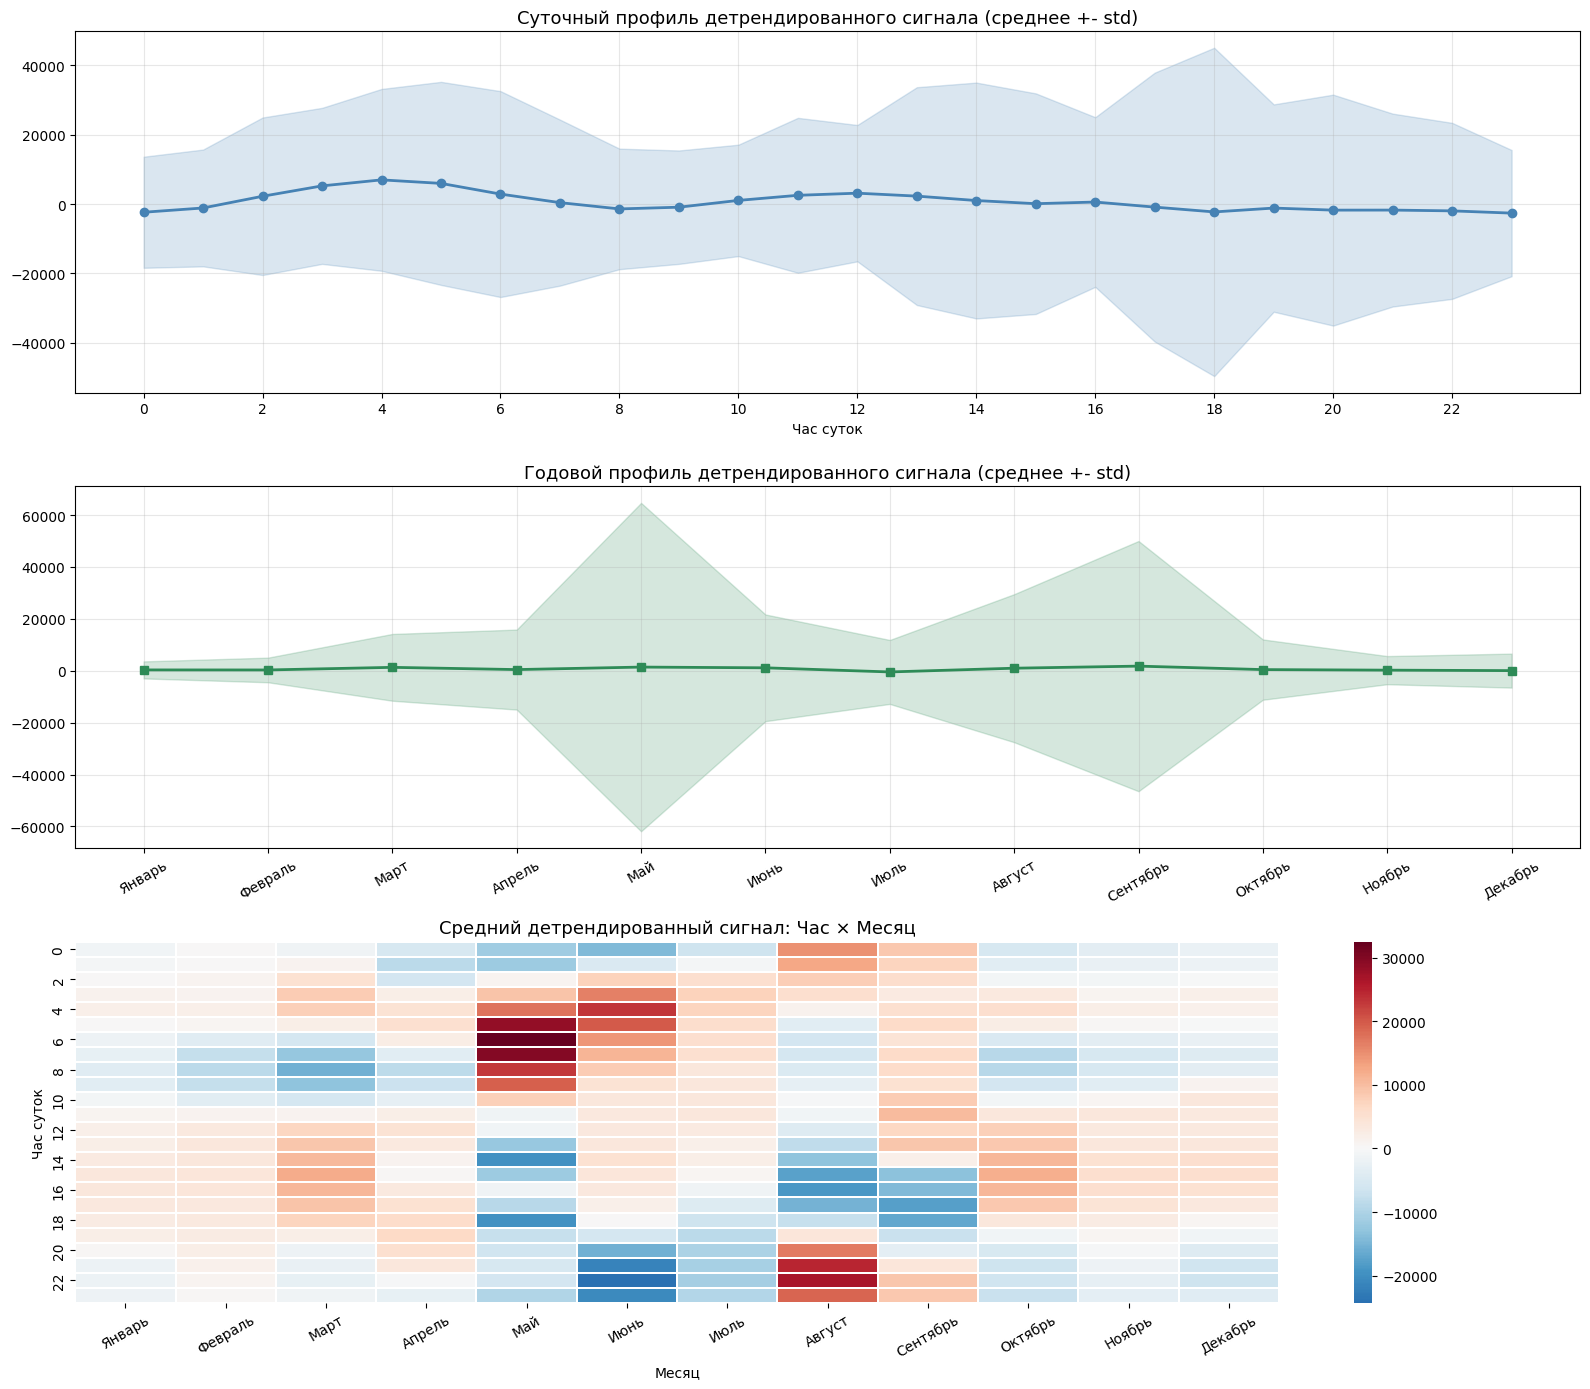

In [15]:
df_clean = df[df['is_artifact'] == 0].dropna(subset=['value_detrended'])

month_order = ['Январь','Февраль','Март','Апрель','Май','Июнь',
               'Июль','Август','Сентябрь','Октябрь','Ноябрь','Декабрь']
month_order = [m for m in month_order if m in df_clean['month_name'].unique()]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

hourly = df_clean.groupby('hour')['value_detrended'].agg(['mean', 'std'])
axes[0].plot(hourly.index, hourly['mean'], marker='o', color='steelblue', lw=2)
axes[0].fill_between(
    hourly.index,
    hourly['mean'] - hourly['std'],
    hourly['mean'] + hourly['std'],
    alpha=0.2, color='steelblue'
)
axes[0].set_title('Суточный профиль детрендированного сигнала (среднее +- std)', fontsize=13)
axes[0].set_xlabel('Час суток')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

monthly = df_clean.groupby('month_name')['value_detrended'].agg(['mean', 'std']).reindex(month_order)
axes[1].plot(range(len(monthly)), monthly['mean'], marker='s', color='seagreen', lw=2)
axes[1].fill_between(
    range(len(monthly)),
    monthly['mean'] - monthly['std'],
    monthly['mean'] + monthly['std'],
    alpha=0.2, color='seagreen'
)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(month_order, rotation=30)
axes[1].set_title('Годовой профиль детрендированного сигнала (среднее +- std)', fontsize=13)
axes[1].grid(True, alpha=0.3)

pivot = df_clean.pivot_table(
    values='value_detrended',
    index='hour',
    columns='month_number',
    aggfunc='mean'
)
pivot.columns = [month_order[i-1] for i in pivot.columns if i-1 < len(month_order)]
sns.heatmap(pivot, cmap='RdBu_r', center=0, ax=axes[2], linewidths=0.3)
axes[2].set_title('Средний детрендированный сигнал: Час × Месяц', fontsize=13)
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Час суток')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Спокойных точек: 8533669 (84.7%)
Бурных точек: 1430307 (14.2%)


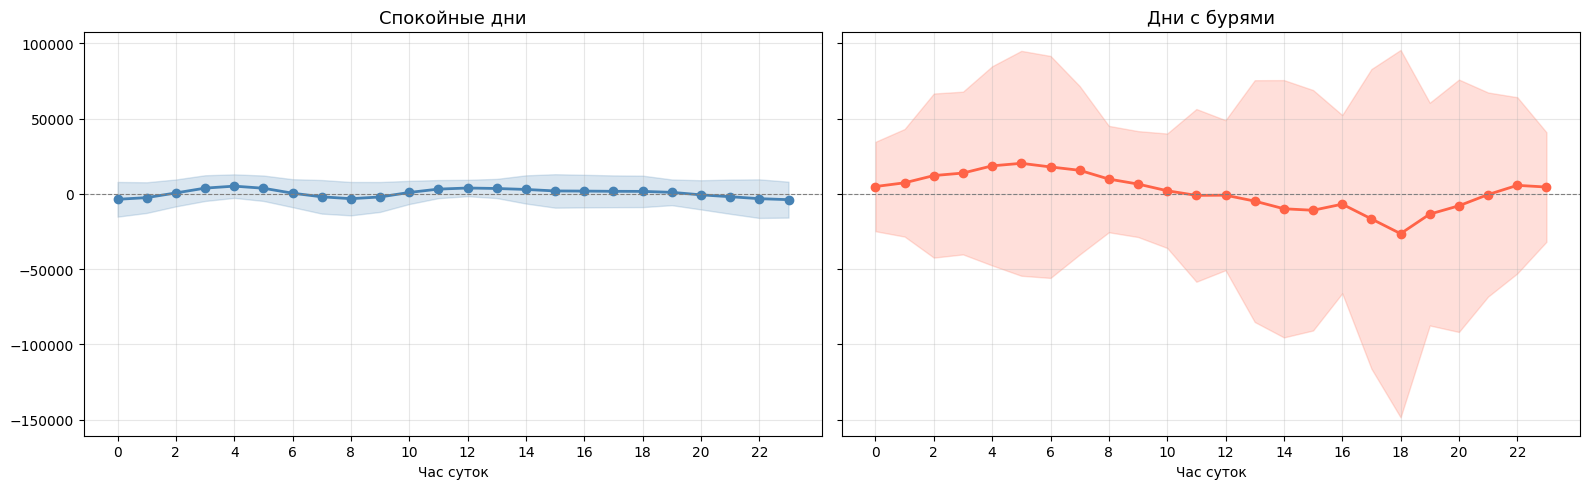

In [16]:
STORM_THRESHOLD = 15000

calm_mask = df['rolling_std_24h'] < STORM_THRESHOLD
storm_mask = df['rolling_std_24h'] >= STORM_THRESHOLD

print(f'Спокойных точек: {calm_mask.sum()} ({100*calm_mask.mean():.1f}%)')
print(f'Бурных точек: {storm_mask.sum()} ({100*storm_mask.mean():.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

calm_hourly  = df[calm_mask].groupby('hour')['value_detrended'].agg(['mean','std'])
storm_hourly = df[storm_mask].groupby('hour')['value_detrended'].agg(['mean','std'])

for ax, data, title, color in zip(
    axes,
    [calm_hourly, storm_hourly],
    ['Спокойные дни', 'Дни с бурями'],
    ['steelblue', 'tomato']
):
    ax.plot(data.index, data['mean'], marker='o', color=color, lw=2)
    ax.fill_between(data.index,
                    data['mean'] - data['std'],
                    data['mean'] + data['std'],
                    alpha=0.2, color=color)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Час суток')
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linestyle='--', lw=0.8)

plt.tight_layout()
plt.show()

## Удаляем лишние колонки



In [17]:
cols_to_drop = [
    'value',         # исходный - заменён на value_detrended
    'value_clean',   # промежуточный
    'value_medfilt', # промежуточный
    'seconds',       # заменён признаками времени
    'quality',       # не нужен после очистки
    'accuracy',      # не нужен
    'diff',          # служебный
    'is_artifact',   # служебный
    'trend_7d',      # служебный
    'accuracy_flag', # служебный
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_final = df.drop(columns=cols_to_drop)

df_final = df_final.reset_index(drop=True)

print('Финальные колонки:')
for col in df_final.columns:
    print(f'  {col}: {df_final[col].dtype}')

print(f'\nРазмер финального датафрейма: {df_final.shape}')
print(f'NaN в финальном датафрейме: {df_final.isna().sum().sum()}')
df_final.tail()

Финальные колонки:
  value_detrended: float64
  minute: int64
  hour: int64
  day: int64
  day_of_week: int64
  week_number: int64
  day_name: object
  month_number: int64
  month_name: object
  day_of_year: int64
  sin_hour: float64
  cos_hour: float64
  lag_mean_30min: float64
  lag_mean_1h: float64
  lag_mean_3h: float64
  lag_mean_6h: float64
  diff_1h: float64
  diff_3h: float64
  slope_1h: float64
  slope_3h: float64
  sin_dayofyear: float64
  cos_dayofyear: float64
  value_ema: float64
  rolling_std_24h: float64

Размер финального датафрейма: (10079174, 24)
NaN в финальном датафрейме: 1150186


,value_detrended,minute,hour,day,day_of_week,week_number,day_name,month_number,month_name,day_of_year,...,lag_mean_3h,lag_mean_6h,diff_1h,diff_3h,slope_1h,slope_3h,sin_dayofyear,cos_dayofyear,value_ema,rolling_std_24h
10079169,-33200.785565,18,23,349,1,50,Вторник,12,Декабрь,349,...,-43843.600035,-27401.195251,23602.344921,-951.597470,14467.967625,-32875.767084,-0.271958,0.962309,-40215.118263,15280.517683
10079170,-33200.620585,18,23,349,1,50,Вторник,12,Декабрь,349,...,-43843.864368,-27405.980826,23582.243681,-949.605565,14499.313145,-32866.721312,-0.271958,0.962309,-40203.437168,15281.214949
10079171,-33200.455655,18,23,349,1,50,Вторник,12,Декабрь,349,...,-43844.128147,-27410.767491,23546.142550,-919.613859,14530.575165,-32857.657807,-0.271958,0.962309,-40191.775250,15281.912095
10079172,-33200.290724,18,23,349,1,50,Вторник,12,Декабрь,349,...,-43844.383596,-27415.554692,23516.041498,-897.622361,14561.783685,-32848.581568,-0.271958,0.962309,-40180.132478,15282.609149
10079173,-33200.125843,18,23,349,1,50,Вторник,12,Декабрь,349,...,-43844.632935,-27420.342151,23483.940417,-889.630952,14592.912039,-32839.495374,-0.271958,0.962309,-40168.508820,15283.306193


## Выводы


1. Шаг датчика - 3 секунды, ряд практически регулярный (29 нерегулярных шагов из 10 млн)
2. Колонка accuracy - 27 ненулевых из 10 млн, можно игнорировать
3. Выбросы - 16 точек с производной больше 50 000, заменены на NaN
4. Отрицательные значения - это бури, не артефакты, оставлены в данных
5. Дрейф - за год сигнал вырос с 90 000 до 160 000, убран через скользящее среднее 7 суток
6. Лаг 1ч - корреляция 0.933, обязателен для модели
7. rolling_std_24h - главный признак для детектора бурь

### Финальные признаки для модели:
 `value_detrended` - целевой сигнал
 `hour`, `day_name`, `week_number`, `month_name`, `month_number`, `day_of_year` - время
 `lag_mean_1h` - память сигнала
 `value_ema` - локальный тренд
 `rolling_std_24h` - признак активности бури

In [18]:
df_final.columns

Index(['value_detrended', 'minute', 'hour', 'day', 'day_of_week',
       'week_number', 'day_name', 'month_number', 'month_name', 'day_of_year',
       'sin_hour', 'cos_hour', 'lag_mean_30min', 'lag_mean_1h', 'lag_mean_3h',
       'lag_mean_6h', 'diff_1h', 'diff_3h', 'slope_1h', 'slope_3h',
       'sin_dayofyear', 'cos_dayofyear', 'value_ema', 'rolling_std_24h'],
      dtype='object')

In [19]:
df_final.to_parquet('prepared_df.parquet', index=False)